<a href="https://colab.research.google.com/github/KevintheChris/My_Datascience_repository/blob/main/Viagens_realizadas_%C3%A0_servi%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados - Portal da Transparência
Fazendo uma análise exploratoria de dados do dataset público do Portal da Transparência, focado no Sistema de Concessão de Diárias e Passagens (SCDP).

In [ ]:
#Importando as bibliotecas e os dados que serão utilizados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
caminho_dados = "/content/drive/MyDrive/Minhas Análises de dados/Viagens públicas/2025_Viagem.csv"
import matplotlib.ticker as ticker

# Função mestre para formatar os eixos (R$ 100 Mi, R$ 10 mil, etc)
def formata_moeda(x, pos):
    if x >= 1_000_000_000:
        return f'R$ {x*1e-9:.1f} Bi'
    if x >= 1_000_000:
        return f'R$ {x*1e-6:.1f} Mi'
    elif x >= 1_000:
        return f'R$ {x*1e-3:.0f} mil'
    return f'R$ {x:.0f}'

formatter = ticker.FuncFormatter(formata_moeda)


In [ ]:
#Lendo os dados
df_viagens = pd.read_csv(caminho_dados, encoding= 'Windows-1252', sep = ';', decimal = ',')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:.2f}'.format)

#Criando uma nova coluna para despesas
df_viagens['Despesas'] = df_viagens['Valor diárias'] + df_viagens['Valor passagens'] + df_viagens['Valor outros gastos']

#Ajustando valores nulos na coluna de cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna('NÃO IDENTIFICADO')

#Convertendo coluna de datas
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'],format='%d/%m/%Y')
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'],format='%d/%m/%Y')

#Criando novas colunas de datas
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days


In [ ]:
#Criando tabela consolidada
df_viagens_consolidado = (df_viagens.groupby('Cargo')
.agg(
    despesa_media = ('Despesas' , 'mean'),
    duracao_media =('Dias de viagem','mean'),
    despesas_totais=('Despesas' , 'sum'),
    destino_mais_frequente =('Destinos',pd.Series.mode),
    num_viagens = ('Nome','count')
    )
  .reset_index()
  .sort_values(by='despesas_totais', ascending=False)
)
#Filtrando tabela consolidada por cargos relevantes(>1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion']> 0.01, 'Cargo']
filtro= df_viagens_consolidado['Cargo'].isin(cargos_relevantes)
#Tabela final consolidada
df_final = df_viagens_consolidado[filtro].sort_values(by='num_viagens', ascending=False)

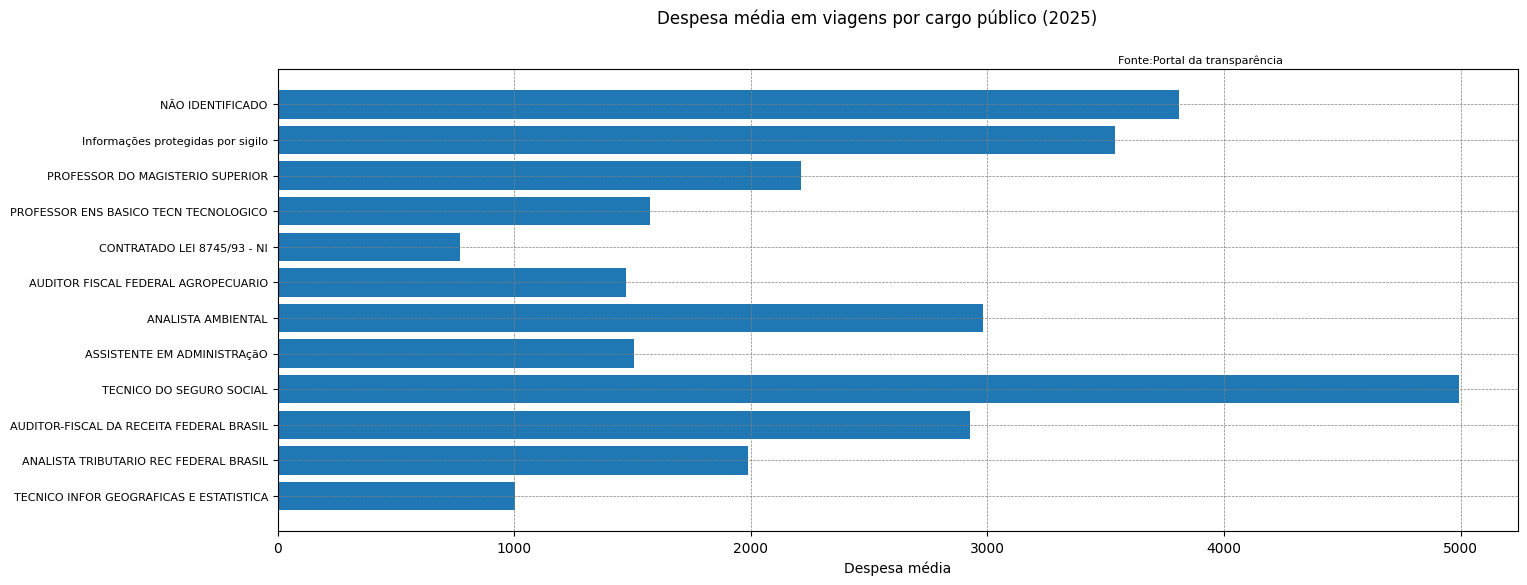

In [ ]:
#Criando a figura
fig, ax = plt.subplots(figsize=(16,6))

#Plotando o gráfico
ax.barh(df_final['Cargo'],df_final['despesa_media'])
ax.invert_yaxis()

#Ajustando o gráfico
fig.suptitle('Despesa média em viagens por cargo público (2025)')
plt.figtext(0.65 , 0.89,'Fonte:Portal da transparência', fontsize=8)
plt.grid(color='gray', linestyle = '--', linewidth=0.5)
plt.yticks(fontsize=8)
plt.xlabel('Despesa média')
#Exibindo gráfico
plt.show()

In [ ]:
# 1. Proporção do gasto
df_viagens['pct_passagem'] = df_viagens['Valor passagens'] / df_viagens['Despesas']

# 2. Agrupamento por mês para ver evolução temporal
df_mensal = df_viagens.groupby(df_viagens['Período - Data de início'].dt.to_period('M')).agg({
    'Despesas': 'sum',
    'Identificador do processo de viagem': 'count'
}).rename(columns={'Identificador do processo de viagem': 'Qtd Viagens'})

# 3. Identificar viagens que pegam final de semana
df_viagens['Final_Semana'] = df_viagens.apply(lambda x: 1 if x['Período - Data de início'].weekday() >= 4 else 0, axis=1)

df_final

,Cargo,despesa_media,duracao_media,despesas_totais,destino_mais_frequente,num_viagens
545,NÃO IDENTIFICADO,3811.37,7.55,1090211753.09,Brasília/DF,286042
496,Informações protegidas por sigilo,3539.92,7.45,389454950.44,Informações protegidas por sigilo,110018
634,PROFESSOR DO MAGISTERIO SUPERIOR,2212.30,3.53,112926943.94,Brasília/DF,51045
635,PROFESSOR ENS BASICO TECN TECNOLOGICO,1573.72,2.31,59939819.79,Brasília/DF,38088
356,CONTRATADO LEI 8745/93 - NI,772.51,2.10,14156211.00,Sena Madureira/AC,18325
245,AUDITOR FISCAL FEDERAL AGROPECUARIO,1470.76,1.95,25260344.82,Brasília/DF,17175
96,ANALISTA AMBIENTAL,2982.16,5.43,48009850.71,Brasília/DF,16099
210,ASSISTENTE EM ADMINISTRAçãO,1507.86,2.17,16333163.17,Brasília/DF,10832
760,TECNICO DO SEGURO SOCIAL,4991.00,12.16,48677244.99,Brasília/DF,9753
246,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,2925.90,2.98,26584710.05,Brasília/DF,9086


### 1. Eficiência e Composição de Custos
O objetivo aqui é ver quanto cada dia de viagem custa de fato e qual o "peso" das passagens no orçamento total.

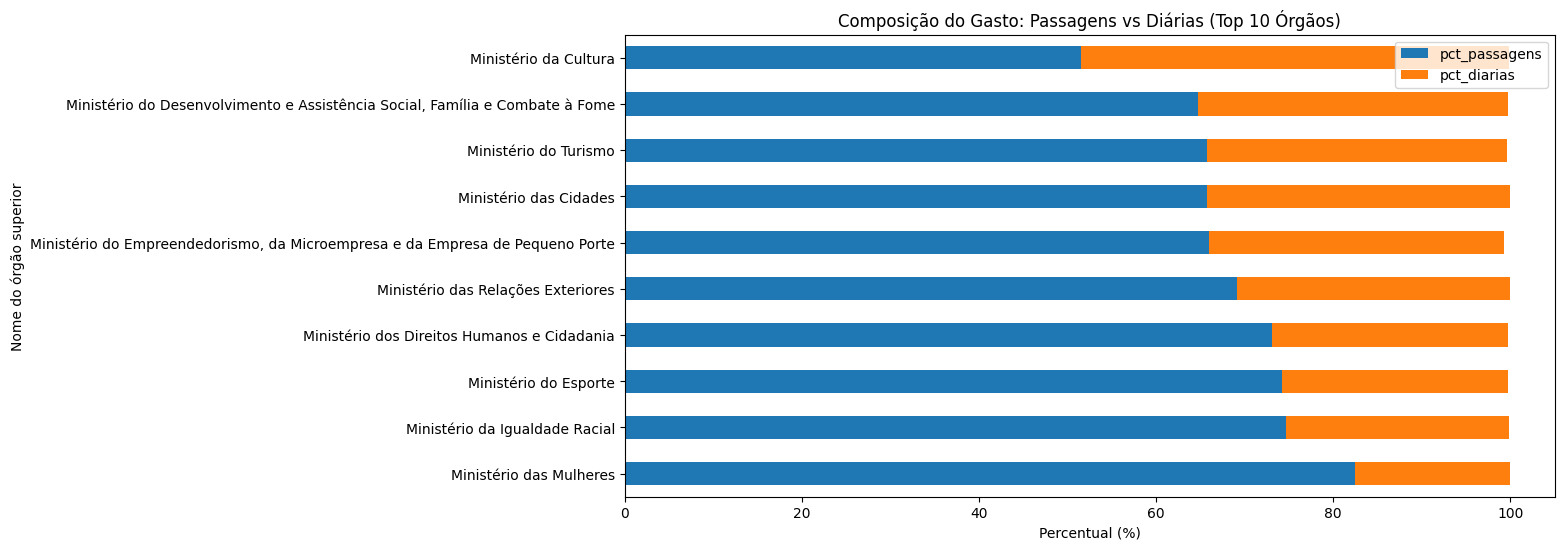

In [ ]:
# Evitando divisão por zero se a viagem for de 0 dias (mesmo dia)
df_viagens['Dias de viagem'] = df_viagens['Dias de viagem'].replace(0, 1)

# Cálculo de métricas
df_viagens['Custo_Diario'] = df_viagens['Despesas'] / df_viagens['Dias de viagem']
df_viagens['pct_passagens'] = (df_viagens['Valor passagens'] / df_viagens['Despesas']) * 100
df_viagens['pct_diarias'] = (df_viagens['Valor diárias'] / df_viagens['Despesas']) * 100

# Agrupando por Órgão Superior para ver a composição
df_comp = df_viagens.groupby('Nome do órgão superior')[['pct_passagens', 'pct_diarias']].mean().sort_values('pct_passagens', ascending=False).head(10)

# Plotando Composição de Gastos (Exemplo: Top 10 Órgãos)
df_comp.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Composição do Gasto: Passagens vs Diárias (Top 10 Órgãos)')
plt.xlabel('Percentual (%)')
plt.show()

### 2. Análise Temporal e "Efeito Dezembro"
Queremos observar se o gasto acelera conforme o ano chega ao fim, o que é um comportamento clássico da execução orçamentária.

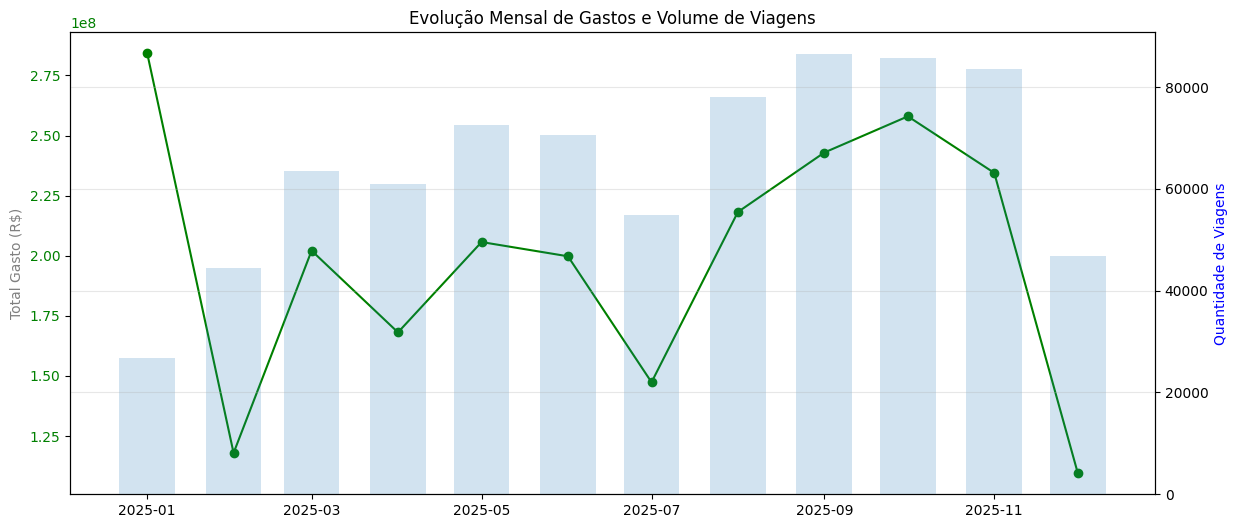

In [ ]:
# Agrupando por mês (usando o período de início)
df_temporal = df_viagens.groupby(df_viagens['Período - Data de início'].dt.to_period('M')).agg(
    total_gasto=('Despesas', 'sum'),
    qtd_viagens=('Identificador do processo de viagem', 'count')
)

# Convertendo o índice de volta para timestamp para o matplotlib entender
df_temporal.index = df_temporal.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Linha de Gasto Total
ax1.plot(df_temporal.index, df_temporal['total_gasto'], color='green', marker='o', label='Gasto Total (R$)')
ax1.set_ylabel('Total Gasto (R$)', color='gray')
ax1.tick_params(axis='y', labelcolor='green')

# Eixo secundário para Quantidade de Viagens
ax2 = ax1.twinx()
ax2.bar(df_temporal.index, df_temporal['qtd_viagens'], alpha=0.2, label='Qtd Viagens', width=20)
ax2.set_ylabel('Quantidade de Viagens', color='blue')

plt.title('Evolução Mensal de Gastos e Volume de Viagens')
plt.grid(alpha=0.3)
plt.show()

### 3. Concentração (Os "Top Travelers")
Aqui aplicamos o Princípio de Pareto para ver se uma minoria de servidores é responsável pela maioria dos custos.

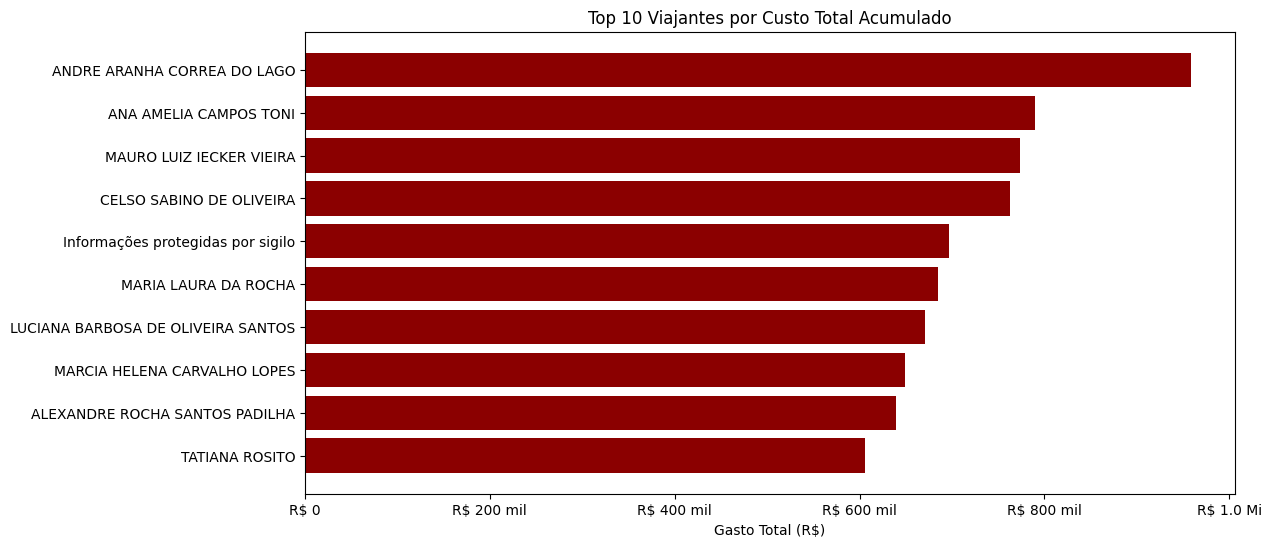

In [ ]:
# Agrupando por viajante
df_viajantes = df_viagens.groupby(['CPF viajante', 'Nome']).agg(
    total_gasto=('Despesas', 'sum')
).sort_values('total_gasto', ascending=False).head(10).reset_index()

# Criando a figura e o eixo (O SEGREDO ESTÁ AQUI)
fig, ax = plt.subplots(figsize=(12, 6))

# Plotando
ax.barh(df_viajantes['Nome'], df_viajantes['total_gasto'], color='darkred')

# APLICANDO A FORMATAÇÃO
ax.xaxis.set_major_formatter(formatter)

ax.invert_yaxis() # Maior gasto no topo
ax.set_title('Top 10 Viajantes por Custo Total Acumulado')
ax.set_xlabel('Gasto Total (R$)')
plt.show()

/tmp/ipython-input-3218538232.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_destinos, x='total_gasto', y='Destinos', palette='viridis', ax=ax)


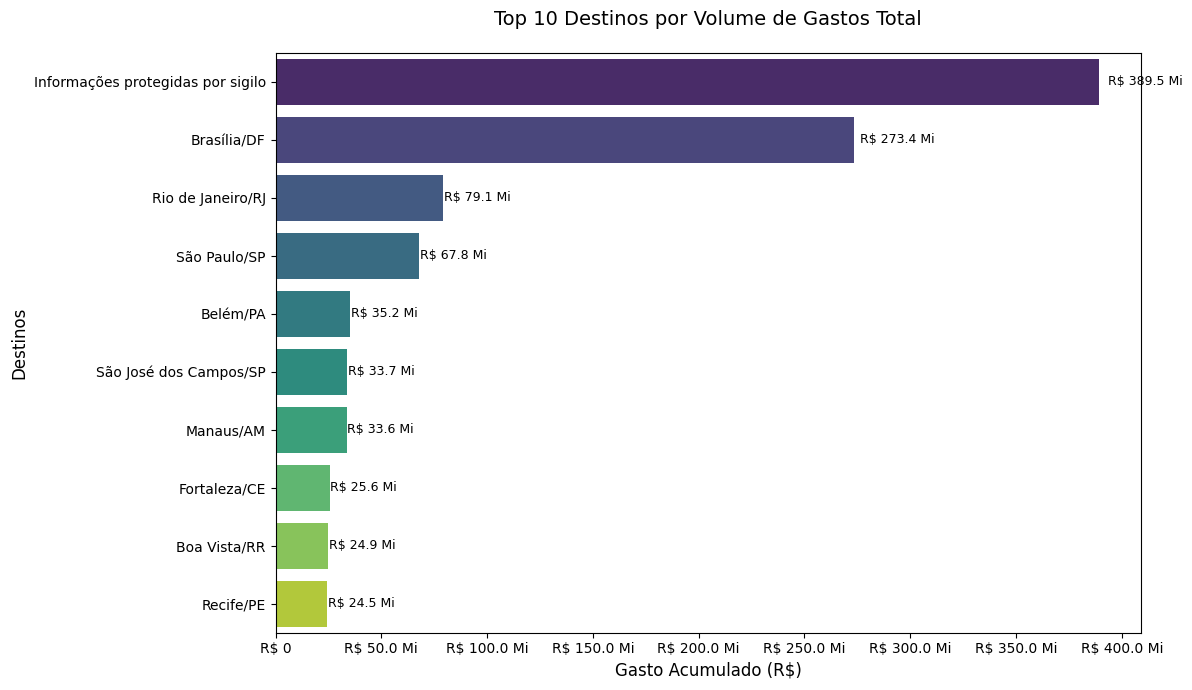

In [ ]:
# Agrupando por destino
df_destinos = df_viagens.groupby('Destinos').agg(
    total_gasto=('Despesas', 'sum'),
    qtd_viagens=('Identificador do processo de viagem', 'count')
).sort_values('total_gasto', ascending=False).head(10).reset_index()

# Criando a figura
fig, ax = plt.subplots(figsize=(12, 7))

# Plotando
sns.barplot(data=df_destinos, x='total_gasto', y='Destinos', palette='viridis', ax=ax)

# APLICANDO A FORMATAÇÃO NO EIXO X (Isso remove o 1e8)
ax.xaxis.set_major_formatter(formatter)

# Ajustes finais de layout
ax.set_title('Top 10 Destinos por Volume de Gastos Total', fontsize=14, pad=20)
ax.set_xlabel('Gasto Acumulado (R$)', fontsize=12)
ax.set_ylabel('Destinos', fontsize=12)

# Adicionando rótulos de dados nas barras para facilitar a leitura rápida
for i, v in enumerate(df_destinos['total_gasto']):
    ax.text(v + (v * 0.01), i, formata_moeda(v, None), color='black', va='center', fontsize=9)

plt.tight_layout()
plt.show()